Var(X_t) target match: 0.997
Mean E[v_T]: 0.10000  |  Expected ξ₀(T): 0.10000
Mean relative deviation E[v_t] vs ξ₀(t): 0.000%
∫|E[v_t] - ξ₀(t)| dt  = 0.000000
Relative integral deviation = 0.000%


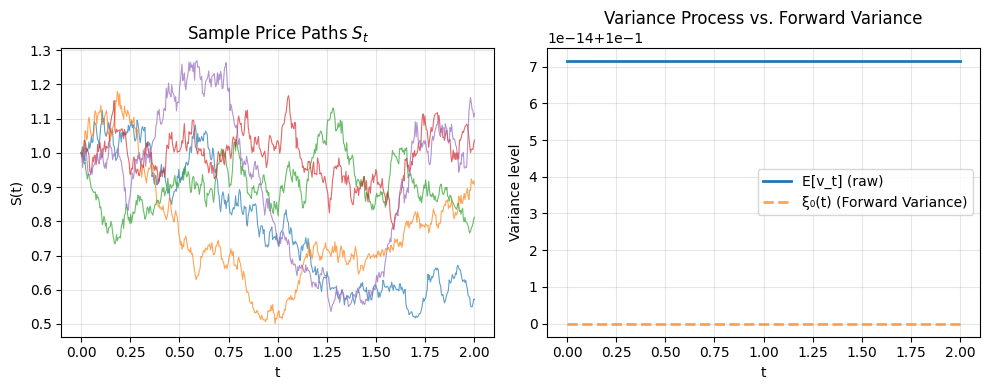

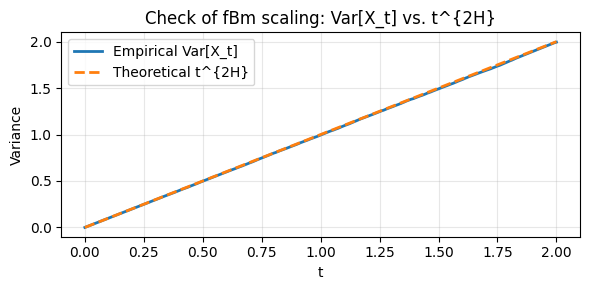

Final Var[X_T] empirical = 1.9942, theoretical = 2.0000
[ 0.00000000e+00 -5.81559664e-05  2.68665874e-04 -3.39004857e-05
 -3.40837527e-04 -3.10888924e-04 -1.08625347e-04 -7.77882426e-06
 -1.96378284e-04 -3.18515301e-04]


In [301]:
# Rough Bergomi IV surfaces via rDonsker fBm — Stable IV Extraction + OTM Options
# --------------------------------------------------------------------------------------------------------
# Features:
# - Constant time grid (consistent discretization)
# - Randomized Maturities (±15%)
# - OTM pricing (Calls for K>=S0, Puts for K<S0)
# - Stable implied vol inversion (clipping + NaN handling)
# - Piecewise constant xi0, Antithetic variates, batch seeding
# --------------------------------------------------------------------------------------------------------

import numpy as np
from dataclasses import dataclass
from typing import List, Dict
from scipy.stats import norm
from scipy.interpolate import griddata

# -------------------------------------------------------------
# Parameter structures
# -------------------------------------------------------------

@dataclass
class RBergomiParams:
    eta: float
    rho: float
    H: float
    xi0_knots: np.ndarray

@dataclass
class SimulationConfig:
    M: int = 20000
    n: int = 1200
    T_max: float = 2.0
    S0: float = 1.0
    strikes: np.ndarray = None
    maturities: np.ndarray = None
    batch_size: int = 5000
    G: int = 10

    def __post_init__(self):
        if self.strikes is None:
            self.strikes = np.array([0.5,0.6,0.7,0.8,0.9,1.0,1.1,1.2,1.3,1.4,1.5])
        if self.maturities is None:
            self.maturities = np.array([0.1,0.3,0.6,0.9,1.2,1.5,1.8,2.0])

# -------------------------------------------------------------
# rDonsker fractional Brownian motion simulator
# -------------------------------------------------------------

def fBm_path_rDonsker(grid_points: int, M: int, H: float, T: float) -> np.ndarray:
    """
    rDonsker fractional Brownian motion paths with correct variance scaling.
    Ensures Var[X_t] ≈ t^{2H}.
    """
    dt = 1 / (grid_points - 1)
    dw = np.random.normal(0.0, (dt**H), size=(M, grid_points - 1))
    i = np.arange(1, grid_points)
    # "Optimal" Donsker kernel (from Bayer, Friz, Gatheral 2016)
    opt_k = ((i**(2*H) - (i-1)**(2*H)) / (2*H)) ** 0.5

    Y = np.zeros((M, grid_points))
    for m in range(M):
        conv = np.convolve(opt_k, dw[m, :])[:grid_points - 1]
        Y[m, 1:] = conv

    # empirically normalize to Var[X_T] = T^{2H}
    scale = T**H*np.sqrt(2*H)
    Y *= scale
    return Y

# -------------------------------------------------------------
# Piecewise constant forward variance curve
# -------------------------------------------------------------

def build_xi0_piecewise_constant(knots: np.ndarray, t_grid: np.ndarray) -> np.ndarray:
    T_max = t_grid[-1]
    knot_times = np.linspace(0.0, T_max, len(knots))
    idx = np.digitize(t_grid, knot_times) - 1
    idx = np.clip(idx, 0, len(knots) - 1)
    return knots[idx]

# -------------------------------------------------------------
# Price simulation with correlated Brownian motions
# -------------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt

import numpy as np
import matplotlib.pyplot as plt

def simulate_price_paths(
    S0: float,
    t: np.ndarray,
    X: np.ndarray,
    dw: np.ndarray,
    dW_perp: np.ndarray,
    xi0_t: np.ndarray,
    eta: float,
    rho: float,
    H: float,
    visualize: bool = True,
    correct_bias: bool = False
) -> np.ndarray:
    """
    Simulate price paths under the rough Bergomi model.
    Includes visualization of price paths and variance vs. forward variance.
    Optionally applies bias correction to match E[v_t] ≈ ξ₀(t).
    """

    # --- Setup and alignment ---
    n = min(X.shape[1], t.shape[0], dw.shape[1] + 1, xi0_t.shape[0])
    X, t, xi0_t = X[:, :n], t[:n], xi0_t[:n]
    dw, dW_perp = dw[:, :n-1], dW_perp[:, :n-1]
    M = X.shape[0]
    dt = np.mean(np.diff(t))
    t2H = np.power(t, 2.0 * H)

    # --- Variance process ---
    exp_etaX = np.exp(eta * X - 0.5 * eta**2 *t2H)
    v = xi0_t * exp_etaX

    # --- Empirical bias correction (optional) ---
    if correct_bias:
        mean_v = np.mean(v, axis=0)
        bias_corr = xi0_t / np.maximum(mean_v, 1e-12)
        v *= bias_corr

    # --- Price dynamics ---
    dW_S = rho * dw + np.sqrt(max(1.0 - rho * rho, 0.0)) * dW_perp
    logS = np.zeros((M, n))
    logS[:, 0] = np.log(S0)
    logS[:, 1:] = logS[:, [0]] + np.cumsum(
        -0.5 * v[:, :-1] * dt + np.sqrt(np.maximum(v[:, :-1], 0.0)) * dW_S,
        axis=1
    )
    S = np.exp(logS)

    # --- Visualization ---
    if visualize:
        avg_v = np.mean(v, axis=0)
        var_ratio = np.var(X[:, -1]) / np.power(t[-1], 2 * H)

        print(f"Var(X_t) target match: {var_ratio:.3f}")
        print(f"Mean E[v_T]: {avg_v[-1]:.5f}  |  Expected ξ₀(T): {xi0_t[-1]:.5f}")

        # --- Quantitative diagnostics ---
        abs_integral_err = np.trapezoid(np.abs(avg_v - xi0_t), t)
        rel_integral_err = abs_integral_err / np.trapezoid(np.abs(xi0_t), t)
        rel_err = np.mean(np.abs(avg_v - xi0_t) / np.maximum(xi0_t, 1e-8))

        print(f"Mean relative deviation E[v_t] vs ξ₀(t): {rel_err:.3%}")
        print(f"∫|E[v_t] - ξ₀(t)| dt  = {abs_integral_err:.6f}")
        print(f"Relative integral deviation = {rel_integral_err:.3%}")

        # --- Plotting ---
        fig, axes = plt.subplots(1, 2, figsize=(10, 4))

        # Left: Sample Price Paths
        axes[0].plot(t, S[:5, :].T, lw=0.8, alpha=0.7)
        axes[0].set_title("Sample Price Paths $S_t$")
        axes[0].set_xlabel("t")
        axes[0].set_ylabel("S(t)")
        axes[0].grid(alpha=0.3)

        # Right: Variance comparison
        axes[1].plot(t, avg_v, label="E[v_t] (Simulated, bias-corrected)" if correct_bias else "E[v_t] (raw)", lw=2)
        axes[1].plot(t, xi0_t, "--", label="ξ₀(t) (Forward Variance)", lw=2, alpha=0.7)
        axes[1].set_title("Variance Process vs. Forward Variance")
        axes[1].set_xlabel("t")
        axes[1].set_ylabel("Variance level")
        axes[1].legend()
        axes[1].grid(alpha=0.3)

        plt.tight_layout()
        plt.show()
                # --- Check: empirical Var[X_t] vs theoretical t^{2H} ---
        emp_var_X = np.var(X, axis=0)
        theo_var_X = np.power(t, 2 * H)

        plt.figure(figsize=(6, 3))
        plt.plot(t, emp_var_X, label="Empirical Var[X_t]", lw=2)
        plt.plot(t, theo_var_X, "--", label="Theoretical t^{2H}", lw=2)
        plt.title("Check of fBm scaling: Var[X_t] vs. t^{2H}")
        plt.xlabel("t")
        plt.ylabel("Variance")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

        print(f"Final Var[X_T] empirical = {emp_var_X[-1]:.4f}, theoretical = {theo_var_X[-1]:.4f}")
        print(np.mean(X, axis=0)[:10])

    return S






# -------------------------------------------------------------
# Plain OTM pricing (no control variate)
# -------------------------------------------------------------

def price_calls_plain(ST: np.ndarray, S0: float, Ks: np.ndarray) -> np.ndarray:
    return np.mean(np.maximum(ST[:, None] - Ks[None, :], 0.0), axis=0)

def price_puts_plain(ST: np.ndarray, S0: float, Ks: np.ndarray) -> np.ndarray:
    return np.mean(np.maximum(Ks[None, :] - ST[:, None], 0.0), axis=0)

def price_otm_plain(ST: np.ndarray, S0: float, Ks: np.ndarray) -> np.ndarray:
    calls = price_calls_plain(ST, S0, Ks)
    puts = price_puts_plain(ST, S0, Ks)
    return np.where(Ks >= S0, calls, puts)

# -------------------------------------------------------------
# Black–Scholes pricing + implied vol inversion (robust)
# -------------------------------------------------------------

def bs_call_price(S0, K, T, vol):
    if vol <= 0.0 or T <= 0.0:
        return max(S0 - K, 0.0)
    sT = np.sqrt(T)
    d1 = (np.log(S0 / K) + 0.5 * vol**2 * T) / (vol * sT)
    d2 = d1 - vol * sT
    return S0 * norm.cdf(d1) - K * norm.cdf(d2)

def bs_put_price(S0, K, T, vol):
    if vol <= 0.0 or T <= 0.0:
        return max(K - S0, 0.0)
    sT = np.sqrt(T)
    d1 = (np.log(S0 / K) + 0.5 * vol**2 * T) / (vol * sT)
    d2 = d1 - vol * sT
    return K * norm.cdf(-d2) - S0 * norm.cdf(-d1)

def implied_vol_from_price_otm(S0, K, T, price, tol=1e-7):
    if price < 1e-8:
        return np.nan
    price_func = bs_call_price if K >= S0 else bs_put_price
    a, b = 1e-8, 5.0
    fa = price_func(S0, K, T, a) - price
    fb = price_func(S0, K, T, b) - price
    if fa * fb > 0:
        return np.nan
    for _ in range(80):
        m = 0.5 * (a + b)
        fm = price_func(S0, K, T, m) - price
        if np.sign(fm) == np.sign(fa):
            a, fa = m, fm
        else:
            b, fb = m, fm
        if abs(b - a) < tol:
            break
    vol = max(0.0, 0.5 * (a + b))
    return np.clip(vol, 0.01, 3.0)

def surface_implied_vols_otm(S0, Ks, T, prices):
    ivs = [implied_vol_from_price_otm(S0, float(K), float(T), float(p)) for K, p in zip(Ks, prices)]
    return np.array(ivs)



def fill_nans_edgewise(arr: np.ndarray) -> np.ndarray:
    """
    Fast edge-stable NaN fill for 2D surfaces.
    1. Linear interpolation along each row.
    2. Linear interpolation along each column.
    3. Fill any remaining NaNs (usually corners) with nearest-edge values.
    """
    arr_filled = arr.copy()

    # Step 1: interpolate along rows (axis=1)
    for i in range(arr_filled.shape[0]):
        s = pd.Series(arr_filled[i, :])
        arr_filled[i, :] = s.interpolate(limit_direction="both").to_numpy()

    # Step 2: interpolate along columns (axis=0)
    for j in range(arr_filled.shape[1]):
        s = pd.Series(arr_filled[:, j])
        arr_filled[:, j] = s.interpolate(limit_direction="both").to_numpy()

    # Step 3: any remaining NaNs (at corners) → nearest-edge fill
    nan_mask = np.isnan(arr_filled)
    if np.any(nan_mask):
        # fill with nearest valid value using broadcasting
        valid_mask = ~nan_mask
        x, y = np.indices(arr_filled.shape)
        valid_coords = np.column_stack(np.where(valid_mask))
        valid_values = arr_filled[valid_mask]
        from scipy.spatial import cKDTree
        tree = cKDTree(valid_coords)
        nan_coords = np.column_stack(np.where(nan_mask))
        _, idx = tree.query(nan_coords)
        arr_filled[nan_mask] = valid_values[idx]

    return arr_filled




# -------------------------------------------------------------
# Parameter sampling
# -------------------------------------------------------------

def sample_param_set() -> RBergomiParams:
    xi0_knots = np.array([0.1,  0.1 ,  0.1 ,  0.1   ,  0.1,
        0.1,  0.1,  0.1])
    eta = 0
    rho = 0
    H = 0.5
    return RBergomiParams(eta=eta, rho=rho, H=H, xi0_knots=xi0_knots)

# -------------------------------------------------------------
# Main workflow
# -------------------------------------------------------------

def generate_surfaces(
    num_sets=1,
    forward_curves_per_set=1,
    cfg=SimulationConfig(),
    seed=42,
    randomize_grid=False,
    grid_jitter=0.5
) -> List[Dict]:
    """
    Generate implied volatility surfaces from a Rough Bergomi simulator.
    Simulation is done once on a fine time grid (defined by cfg.n),
    and implied vol surfaces are extracted on coarser (possibly jittered) grids.

    M is scaled linearly between [M_min, M_max] depending on η in [eta_min, eta_max].
    """

    np.random.seed(seed)
    results = []
    
    n, T_max = cfg.n, cfg.T_max
    M = cfg.M
    base_t = np.linspace(0.0, T_max, n)
    dt = base_t[1] - base_t[0]

    for s in range(num_sets):
        params = sample_param_set()
        np.random.seed(seed + s)

        # --- Linearly scale M with η ---
        eta = params.eta
        M_scaled = int(2 * round(M / 2)) 

        # --- Brownian increments (antithetic) ---
        M_half = M_scaled // 2
        dw_half = np.random.normal(0.0, np.sqrt(dt), size=(M_half, n - 1))
        dW_perp_half = np.random.normal(0.0, np.sqrt(dt), size=(M_half, n - 1))
        dw = np.vstack([dw_half, -dw_half])
        dW_perp = np.vstack([dW_perp_half, -dW_perp_half])

        # --- fBm volatility driver & forward variance ---
        X = fBm_path_rDonsker(n, M_scaled, params.H, T_max)
        xi0_t = build_xi0_piecewise_constant(params.xi0_knots, base_t)

        # --- Single fine-grid simulation ---
        S = simulate_price_paths(cfg.S0, base_t, X, dw, dW_perp,
                                 xi0_t, params.eta, params.rho, params.H)

        strikes_base = cfg.strikes
        maturities_base = cfg.maturities

        for j in range(forward_curves_per_set):
            for g_id in range(cfg.G):

                # --- Optional randomized grids ---
                if randomize_grid:
                    ΔK = strikes_base[1] - strikes_base[0]
                    ΔT = maturities_base[1] - maturities_base[0]

                    strikes_shifted = np.clip(
                        strikes_base + np.random.uniform(-grid_jitter * ΔK, grid_jitter * ΔK, len(strikes_base)),
                        0.5, 1.5
                    )
                    maturities_shifted = np.clip(
                        maturities_base + np.random.uniform(-grid_jitter * ΔT, grid_jitter * ΔT, len(maturities_base)),
                        0.01, T_max
                    )
                else:
                    strikes_shifted = strikes_base.copy()
                    maturities_shifted = maturities_base.copy()

                # --- Extract from fine grid ---
                mat_idx = [np.argmin(np.abs(base_t - Tm)) for Tm in maturities_shifted]
                price_surf = np.zeros((len(maturities_shifted), len(strikes_shifted)))
                iv_surf = np.zeros_like(price_surf)

                for mi, idx in enumerate(mat_idx):
                    ST = S[:, idx]
                    prices = price_otm_plain(ST, cfg.S0, strikes_shifted)
                    price_surf[mi, :] = prices
                    iv_surf[mi, :] = surface_implied_vols_otm(cfg.S0, strikes_shifted, base_t[idx], prices)
                    iv_surf = fill_nans_edgewise(iv_surf)

                results.append({
                    "set_id": s,
                    "fwd_id": j,
                    "grid_id": g_id,
                    "params": vars(params),
                    "M_scaled": M_scaled,
                    "grid": {
                        "strikes": strikes_shifted.astype(float),
                        "maturities": maturities_shifted.astype(float),
                    },
                    "price_surface": price_surf,
                    "iv_surface": iv_surf,
                })

    return results



# -------------------------------------------------------------
# Example run
# -------------------------------------------------------------

if __name__ == "__main__":
    cfg = SimulationConfig(M=60000, n=500, T_max=2, S0=1.0, G=10)
    surfaces = generate_surfaces(num_sets=1, forward_curves_per_set=1, cfg=cfg, seed=3232)
    R0 = surfaces[0]


In [300]:
R0["iv_surface"]

array([[0.30638796, 0.30638796, 0.30638796, 0.31939176, 0.31822366,
        0.3184012 , 0.3185985 , 0.31972219, 0.31990138, 0.30938719,
        0.30938719],
       [0.32994901, 0.31334286, 0.31569858, 0.31600346, 0.31636168,
        0.31611455, 0.31627019, 0.31593111, 0.31535451, 0.31539735,
        0.3143533 ],
       [0.31784517, 0.3169692 , 0.31620544, 0.315432  , 0.31534818,
        0.31500776, 0.31536137, 0.31554033, 0.31618332, 0.31650391,
        0.3169733 ],
       [0.31845314, 0.31778661, 0.31697278, 0.31653916, 0.31611015,
        0.31674651, 0.31712052, 0.3173614 , 0.31765682, 0.31783645,
        0.31838235],
       [0.31652068, 0.31566453, 0.31577964, 0.31574395, 0.31549071,
        0.31531659, 0.31567548, 0.31580952, 0.31581146, 0.31581302,
        0.31603624],
       [0.31655935, 0.31601016, 0.31592284, 0.31575573, 0.31551232,
        0.31556276, 0.31588328, 0.31608296, 0.31624352, 0.31631549,
        0.31645012],
       [0.31577495, 0.31537716, 0.31529901, 0.31514061, 0.

In [269]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

def study_integral_error_vs_M_eta(cfg_base, M_values, eta_values,
                                  rho=-0.5, H=0.2, seeds=range(10)):
    """
    Study ∫|E[v_t] - ξ₀(t)| dt for varying η and M.
    ξ₀(t) is fixed to 0.1 for all t to isolate η–M interaction.
    Returns DataFrame and pivot table of mean integral errors.
    Also records average runtime per M.
    """
    records = []
    timing_records = []

    for eta in eta_values:
        print(f"\n=== Studying η = {eta:.2f} ===")
        for M in M_values:
            abs_int_errors = []
            start_time = time.time()

            for seed in seeds:
                np.random.seed(seed)
                n, T_max = cfg_base.n, cfg_base.T_max
                dt = T_max / (n - 1)
                t = np.linspace(0, T_max, n)

                # --- Antithetic stratified sampling ---
                dw_half = np.random.normal(0, np.sqrt(dt), size=(M // 2, n - 1))
                dW_perp_half = np.random.normal(0, np.sqrt(dt), size=(M // 2, n - 1))
                dw = np.vstack([dw_half, -dw_half])
                dW_perp = np.vstack([dW_perp_half, -dW_perp_half])

                # --- Fractional Brownian motion paths ---
                X = fBm_path_rDonsker(n, M, H, T_max)

                # --- Fixed forward variance ξ₀(t) = 0.1 ---
                xi0_t = np.full_like(t, 0.1)

                # --- Compute empirical mean variance ---
                exp_term = eta * X - 0.5 * eta**2 * np.var(X, axis=0, keepdims=True)
                avg_v = np.mean(xi0_t * np.exp(exp_term), axis=0)

                abs_err = np.trapezoid(np.abs(avg_v - xi0_t), t)
                abs_int_errors.append(abs_err)

            runtime = time.time() - start_time
            mean_err = np.mean(abs_int_errors)
            std_err = np.std(abs_int_errors)
            mean_time = runtime / len(seeds)

            print(f"M={M:<6d} → mean={mean_err:.6f}, std={std_err:.6f}, "
                  f"time/seed={mean_time:.2f}s")

            records.append({
                "eta": eta, "M": M,
                "abs_int_err_mean": mean_err,
                "abs_int_err_std": std_err,
                "time_per_seed_s": mean_time
            })
            timing_records.append({"M": M, "mean_time_s": mean_time})



    return None


# ==============================
# Example Run
# ==============================

cfg = SimulationConfig(M=2000, n=500, T_max=2.0)
M_values = [10_000, 20_000, 50_000, 100_000]
eta_values = [3.0, 4.0]

study_integral_error_vs_M_eta(cfg, M_values, eta_values, H=0.2, rho=-0.5)





=== Studying η = 3.00 ===
M=10000  → mean=0.041100, std=0.007372, time/seed=0.55s
M=20000  → mean=0.041054, std=0.016379, time/seed=1.10s
M=50000  → mean=0.025341, std=0.004872, time/seed=2.62s
M=100000 → mean=0.021105, std=0.003118, time/seed=5.44s

=== Studying η = 4.00 ===
M=10000  → mean=0.105164, std=0.013474, time/seed=0.55s
M=20000  → mean=0.132470, std=0.104711, time/seed=1.08s
M=50000  → mean=0.088250, std=0.016798, time/seed=2.70s
M=100000 → mean=0.077600, std=0.016604, time/seed=5.49s


In [68]:
surfaces[0]["iv_surface"]

array([[0.56737256, 0.52764562, 0.45208809, 0.37922961, 0.32003996,
        0.29255901, 0.31309103, 0.35257247, 0.39489505, 0.43598321,
        0.47524271],
       [0.53432946, 0.4574575 , 0.3892081 , 0.33037973, 0.28391299,
        0.26130539, 0.27698134, 0.30925837, 0.34345937, 0.3765211 ,
        0.40757221],
       [0.46456304, 0.39612089, 0.33668053, 0.2861156 , 0.24723654,
        0.22554514, 0.23831223, 0.26454133, 0.29263091, 0.31992731,
        0.34510379],
       [0.40970025, 0.34921003, 0.29732157, 0.252941  , 0.21910545,
        0.19859296, 0.20965573, 0.23193222, 0.25597592, 0.27897996,
        0.30062404],
       [0.36846486, 0.31459828, 0.26822795, 0.22845005, 0.19810122,
        0.17992158, 0.18969637, 0.2095702 , 0.23106319, 0.25162225,
        0.27093303],
       [0.3366698 , 0.28742139, 0.24504629, 0.20876539, 0.18101235,
        0.16357211, 0.1724371 , 0.1904871 , 0.2099402 , 0.22855048,
        0.24599415],
       [0.31261412, 0.26676369, 0.22739922, 0.19370903, 0.

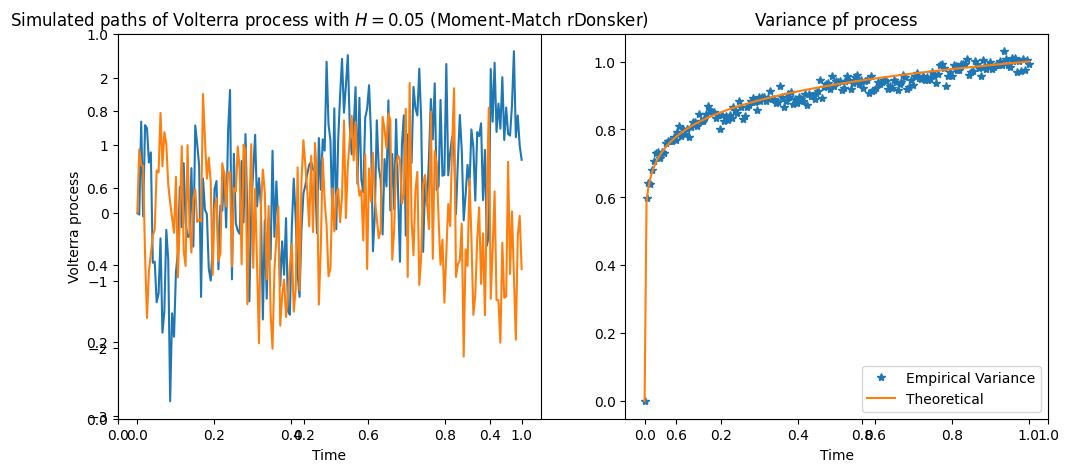

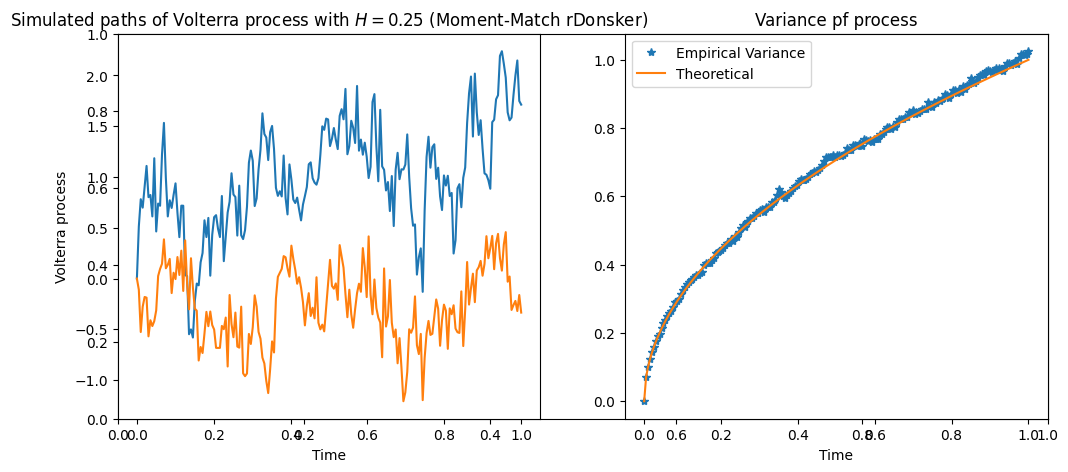

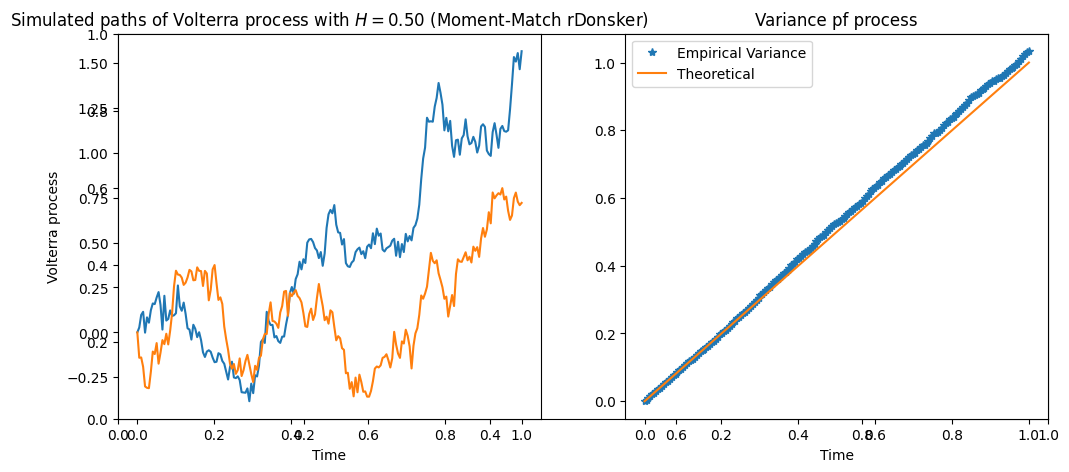

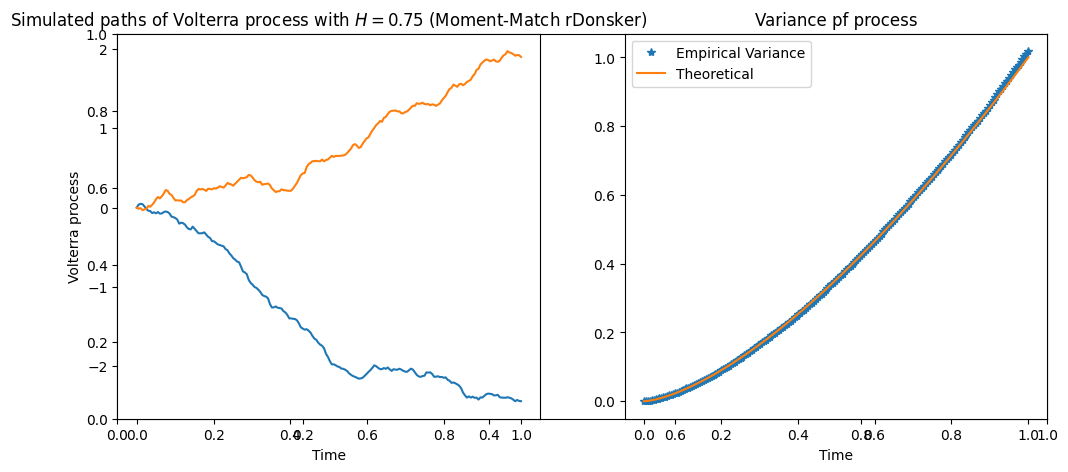

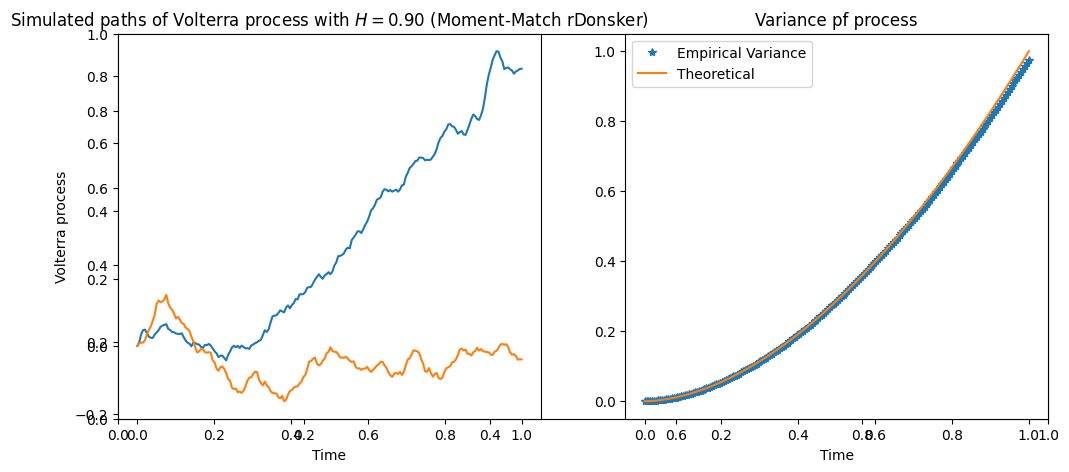

In [231]:
def fBm_path_rDonsker(grid_points: int, M: int, H: float, T: float) -> np.ndarray:
    """
    rDonsker fractional Brownian motion paths with correct variance scaling.
    Ensures Var[X_t] ≈ t^{2H}.
    """
    dt = 1 / (grid_points - 1)
    dw = np.random.normal(0.0, (dt**H), size=(M, grid_points - 1))
    i = np.arange(1, grid_points)
    # "Optimal" Donsker kernel (from Bayer, Friz, Gatheral 2016)
    opt_k = ((i**(2*H) - (i-1)**(2*H)) / (2*H)) ** 0.5

    Y = np.zeros((M, grid_points))
    for m in range(M):
        conv = np.convolve(opt_k, dw[m, :])[:grid_points - 1]
        Y[m, 1:] = conv

    # empirically normalize to Var[X_T] = T^{2H}
    scale = T**H*np.sqrt(2*H)
    Y *= scale
    return Y

import matplotlib.pyplot as plt


T=1
n=200
M=5000

Hs = [0.05,0.25,0.5,0.75,0.9]

times=np.linspace(0,T,n)

for H in Hs:
    
    path=fBm_path_rDonsker(n, M, H, T)
    
    plt.subplots(figsize=(12, 5))
    for i in range(2):
        plt.subplot(1,2,1)
        plt.plot(times,path[i,:])
        
        
    plt.xlabel('Time')
    plt.ylabel('Volterra process')
    plt.title('Simulated paths of Volterra process with $H=%1.2f$ (Moment-Match rDonsker)'%H)
    plt.subplot(1,2,2)
    plt.title('Variance pf process')
    plt.xlabel('Time')
    plt.plot(times,np.var(path,axis=0),'*',label="Empirical Variance")
    plt.plot(times,np.power(times,2*H),label="Theoretical")
    plt.legend()
    plt.show()
        





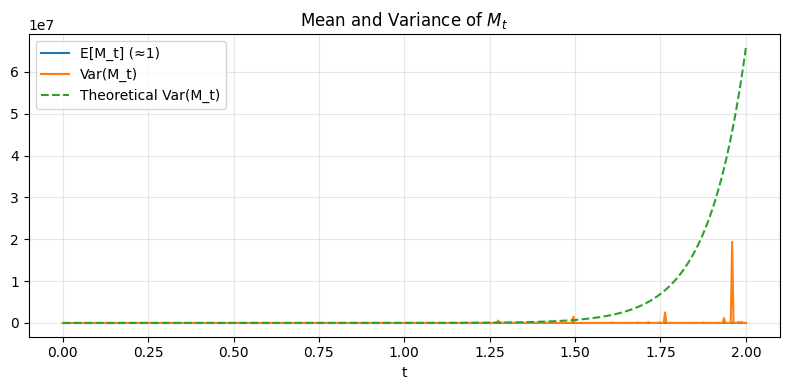

In [260]:
import numpy as np
import matplotlib.pyplot as plt

eta = 3.0
H = 0.5
n = 500
T = 2.0
t = np.linspace(0, T, n)
M = 200000

X = np.random.normal(0, 1, (M, n)) * t**H
M_t = np.exp(eta * X - 0.5 * eta**2 * t**(2*H))

plt.figure(figsize=(8,4))
plt.plot(t, np.mean(M_t, axis=0), label="E[M_t] (≈1)")
plt.plot(t, np.var(M_t, axis=0), label="Var(M_t)")
plt.plot(t, np.exp(eta**2 * t**(2*H)) - 1, "--", label="Theoretical Var(M_t)")
plt.legend()
plt.xlabel("t"); plt.title("Mean and Variance of $M_t$")
plt.grid(alpha=0.3); plt.tight_layout()
plt.show()
